# 🌫️ PM2.5 Maroc — Ensemble, Tuning & Inference (par horizon, resumable)

**Suite du notebook Modeling_Baseline.**

Principes conservés :
- Tuning Optuna LightGBM & CatBoost
- Retrain → tous les horizons H1–H24
- Ensemble : Weighted Blend + Stacking
- Analyse erreurs par ville / heure
- Analyse des pics extrêmes (p99)
- Pipeline d'inférence temps réel
- Sauvegarde modèles finaux + résumé

**Changements demandés :**
- ⚙️ **L'optimisation Optuna est appliquée sur des horizons "ancres"** répartis sur H+1 → H+24
  (au lieu de H+1 uniquement, mais aussi au lieu de TOUS les horizons — trop coûteux).
  Les horizons non-ancres réutilisent les params de l'ancre la plus proche, **ré-entraînés
  sur leur propre target** (donc pas de fuite de données, juste un partage d'hyperparamètres).
  Cela réduit le temps total de tuning de ~60-80% tout en couvrant H+1 ET les horizons
  longs (H+3 à H+24) qui ont des erreurs catastrophiques.
- 🔢 **N_TRIALS réduit** : 20 trials pour H+1 (le plus important), 12 trials pour les
  autres ancres (au lieu de 50 partout).
- 💾 **Checkpoint / Resume automatique** : chaque horizon entraîné (tuning + retrain) est
  sauvegardé immédiatement sur disque. Si le notebook plante (RAM) ou est interrompu, on
  peut relancer la même cellule : elle reprendra exactement où elle s'est arrêtée, sans
  tout refaire.

| Étape | Contenu |
|-------|---------|
| 1 | Reload data + splits |
| 2 | Optuna tuning LightGBM (horizons ancres uniquement, resumable) |
| 3 | Optuna tuning CatBoost (horizons ancres uniquement, resumable) |
| 4 | Retrain avec params (ancre la plus proche) → modèles H1–H24 (resumable) |
| 5 | Ensemble : Weighted Blend + Stacking (par horizon) |
| 6 | Analyse erreurs par ville et par heure |
| 7 | Analyse des pics extrêmes (p99) |
| 8 | Pipeline d'inférence temps réel (une ville, T → T+24) |
| 9 | Sauvegarde modèles finaux + résumé |

## 0. Configuration

In [1]:
# !pip install optuna lightgbm catboost xgboost scikit-learn joblib

In [2]:
import warnings, gc, joblib, json, time, traceback
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, Pool

from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Paths ──────────────────────────────────────────────────────────────────────
FE_DIR      = Path(r"E:\pipeline\test2\feature_engineering_outputs")
MODEL_DIR   = Path(r"E:\pipeline\test2\modeling_outputs")
ENSEMBLE_DIR= Path(r"E:\pipeline\test2\ensemble_All_outputs")
ENSEMBLE_DIR.mkdir(parents=True, exist_ok=True)

# ── Dossiers de checkpoints (sauvegarde en cours d'exécution) ───────────────────
CKPT_DIR     = ENSEMBLE_DIR / "checkpoints"
CKPT_LGB_OPT = CKPT_DIR / "optuna_lgb"     # studies + best params par horizon
CKPT_CB_OPT  = CKPT_DIR / "optuna_cb"
CKPT_LGB_MOD = CKPT_DIR / "models_lgb"     # modèles LGB entraînés par horizon
CKPT_CB_MOD  = CKPT_DIR / "models_cb"      # modèles CB entraînés par horizon
CKPT_PREDS   = CKPT_DIR / "preds"          # prédictions test par horizon (npz)

for d in [CKPT_DIR, CKPT_LGB_OPT, CKPT_CB_OPT, CKPT_LGB_MOD, CKPT_CB_MOD, CKPT_PREDS]:
    d.mkdir(parents=True, exist_ok=True)

# ── Constantes ─────────────────────────────────────────────────────────────────
HORIZONS   = list(range(1, 25))
TARGET_H1  = "target24_h1"
TARGET_COLS= [f"target24_h{h}" for h in HORIZONS]
SEED       = 42

# ── Horizons "ancres" : seuls ces horizons sont optimisés via Optuna.       ──
# Les autres horizons réutilisent les params de l'ancre la plus proche
# (mais sont quand même ré-entraînés sur leur propre target en section 4).
ANCHOR_HORIZONS = [1, 3, 6, 9, 12, 16, 20, 24]

# ── Nombre de trials Optuna par ancre ────────────────────────────────────────
# H+1 reçoit plus de trials car c'est l'horizon le plus important / le plus
# souvent utilisé. Les autres ancres reçoivent moins de trials → gain de temps.
N_TRIALS_H1      = 15
N_TRIALS_OTHER   = 12

def n_trials_for(h):
    return N_TRIALS_H1 if h == 1 else N_TRIALS_OTHER

def nearest_anchor(h, anchors=ANCHOR_HORIZONS):
    '''Retourne l'ancre la plus proche de l'horizon h (en distance absolue).'''
    return min(anchors, key=lambda a: abs(a - h))

np.random.seed(SEED)
print("✅ Config OK")
print(f"📁 Checkpoints → {CKPT_DIR}")
print(f"⚙️  Horizons ancres (tuning Optuna) : {ANCHOR_HORIZONS}")
print(f"🔢 Trials — H+1: {N_TRIALS_H1} | autres ancres: {N_TRIALS_OTHER}")
print(f"➡️  Mapping horizon → ancre :")
for h in HORIZONS:
    a = nearest_anchor(h)
    tag = " (ancre)" if h in ANCHOR_HORIZONS else ""
    print(f"   H+{h:<2d} → ancre H+{a}{tag}")

✅ Config OK
📁 Checkpoints → E:\pipeline\test2\ensemble_All_outputs\checkpoints
⚙️  Horizons ancres (tuning Optuna) : [1, 3, 6, 9, 12, 16, 20, 24]
🔢 Trials — H+1: 15 | autres ancres: 12
➡️  Mapping horizon → ancre :
   H+1  → ancre H+1 (ancre)
   H+2  → ancre H+1
   H+3  → ancre H+3 (ancre)
   H+4  → ancre H+3
   H+5  → ancre H+6
   H+6  → ancre H+6 (ancre)
   H+7  → ancre H+6
   H+8  → ancre H+9
   H+9  → ancre H+9 (ancre)
   H+10 → ancre H+9
   H+11 → ancre H+12
   H+12 → ancre H+12 (ancre)
   H+13 → ancre H+12
   H+14 → ancre H+12
   H+15 → ancre H+16
   H+16 → ancre H+16 (ancre)
   H+17 → ancre H+16
   H+18 → ancre H+16
   H+19 → ancre H+20
   H+20 → ancre H+20 (ancre)
   H+21 → ancre H+20
   H+22 → ancre H+20
   H+23 → ancre H+24
   H+24 → ancre H+24 (ancre)


## 1. Reload Data & Split

In [3]:
df = pd.read_csv(
    FE_DIR / "pm25_supervised_h1_h24.csv",
    engine="pyarrow",
    dtype_backend="pyarrow"
)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values(["city", "datetime"]).reset_index(drop=True)

# Features
with open(FE_DIR / "safe_feature_columns.txt") as f:
    SAFE_FEATURES = [l.strip() for l in f if l.strip()]

le = LabelEncoder()
df["city_enc"] = le.fit_transform(df["city"])

FEAT_NUM = [c for c in SAFE_FEATURES if c != "city"] + ["city_enc"]
FEAT_NUM = [c for c in FEAT_NUM if c in df.columns]
FEAT_CB  = [c for c in SAFE_FEATURES if c in df.columns]   # city string pour CatBoost
CAT_FEAT_CB = ["city"] if "city" in FEAT_CB else []

# Split temporel strict 80/10/10
dates     = df["datetime"].sort_values().unique()
n         = len(dates)
train_end = dates[int(n * 0.80)]
val_end   = dates[int(n * 0.90)]

df_train = df[df["datetime"] <  train_end].copy()
df_val   = df[(df["datetime"] >= train_end) & (df["datetime"] < val_end)].copy()
df_test  = df[df["datetime"] >= val_end].copy()

print(f"Train : {len(df_train):,} | Val : {len(df_val):,} | Test : {len(df_test):,}")
print(f"Features: {len(FEAT_NUM)}")

# Arrays numpy
X_tr  = df_train[FEAT_NUM].astype(float).values.astype(np.float32)
X_va  = df_val[FEAT_NUM].astype(float).values.astype(np.float32)
X_te  = df_test[FEAT_NUM].astype(float).values.astype(np.float32)

Train : 1,052,100 | Val : 131,500 | Test : 131,550
Features: 66


In [4]:
# ── Utilitaires ────────────────────────────────────────────────────────────────
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred):
    num = np.abs(y_pred - y_true)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-8
    return np.mean(num / den) * 100

def evaluate(name, y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = np.array(y_true)[mask], np.array(y_pred)[mask]
    return {
        "Model": name,
        "MAE":   round(mean_absolute_error(y_true, y_pred), 4),
        "RMSE":  round(rmse(y_true, y_pred), 4),
        "SMAPE": round(smape(y_true, y_pred), 4),
        "R2":    round(r2_score(y_true, y_pred), 4),
        "N":     int(mask.sum()),
    }

def get_masks(target_col, split="train"):
    if split == "train": return df_train[target_col].notna().values
    if split == "val":   return df_val[target_col].notna().values
    return df_test[target_col].notna().values

RESULTS = []
print("✅ Utilitaires OK")

✅ Utilitaires OK


In [5]:
# ── Système de checkpoint générique ───────────────────────────────────────────
# Permet de sauvegarder/recharger l'avancement après CHAQUE horizon,
# pour reprendre exactement où on s'est arrêté en cas de pause / crash RAM.

def ckpt_path_json(folder, h):
    return folder / f"h{h}.json"

def ckpt_path_pkl(folder, h, ext="pkl"):
    return folder / f"h{h}.{ext}"

def load_json_ckpt(folder, h):
    p = ckpt_path_json(folder, h)
    if p.exists():
        with open(p) as f:
            return json.load(f)
    return None

def save_json_ckpt(folder, h, data):
    p = ckpt_path_json(folder, h)
    tmp = p.with_suffix(".tmp")
    with open(tmp, "w") as f:
        json.dump(data, f, indent=2, default=str)
    tmp.replace(p)  # écriture atomique

def is_done(folder, h, marker="best_params"):
    data = load_json_ckpt(folder, h)
    return data is not None and marker in data

print("✅ Système de checkpoint prêt")

✅ Système de checkpoint prêt


---
## 2. Optuna Tuning — LightGBM (horizons ancres uniquement)
> ⚠️ **Changement** : on n'optimise plus seulement H+1, ni TOUS les horizons (trop coûteux),
> mais un sous-ensemble **d'horizons ancres** (`ANCHOR_HORIZONS`) répartis sur H+1 → H+24,
> avec moins de trials par horizon (`N_TRIALS_H1` pour H+1, `N_TRIALS_OTHER` pour les autres).
>
> 💾 **Resumable** : chaque ancre terminée écrit `checkpoints/optuna_lgb/h{H}.json`
> (best params + best MAE). Si la cellule est relancée, les ancres déjà traitées sont
> sautées automatiquement.

In [6]:
def lgb_objective_factory(X_tr_h, y_tr_h, X_va_h, y_va_h):
    lgb_tr = lgb.Dataset(X_tr_h, label=y_tr_h, free_raw_data=False)
    lgb_va = lgb.Dataset(X_va_h, label=y_va_h, reference=lgb_tr, free_raw_data=False)

    def objective(trial):
        params = {
            "objective":         "regression",
            "metric":            "mae",
            "verbosity":         -1,
            "n_jobs":            -1,
            "random_state":      SEED,
            "num_leaves":        trial.suggest_int("num_leaves", 31, 255),
            "max_depth":         trial.suggest_int("max_depth", 4, 12),
            "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 1.0),
        }
        model = lgb.train(
            params, lgb_tr,
            num_boost_round=1000,
            valid_sets=[lgb_va],
            callbacks=[
                lgb.early_stopping(40, verbose=False),
                lgb.log_evaluation(-1),
            ]
        )
        preds = model.predict(X_va_h)
        return mean_absolute_error(y_va_h, preds)

    return objective, lgb_tr, lgb_va


best_lgb_params_per_h = {}

print(f"🔍 Optuna LightGBM — horizons ancres {ANCHOR_HORIZONS} "
      f"(H+1: {N_TRIALS_H1} trials, autres: {N_TRIALS_OTHER} trials)...\n")

for h in ANCHOR_HORIZONS:
    tc = f"target24_h{h}"
    n_trials = n_trials_for(h)

    # ── Resume : si cette ancre est déjà faite, on charge et on passe ──
    if is_done(CKPT_LGB_OPT, h):
        ck = load_json_ckpt(CKPT_LGB_OPT, h)
        best_lgb_params_per_h[h] = ck["best_params"]
        print(f"⏭️  H+{h:<2d} déjà optimisé (MAE val={ck['best_value']:.4f}) — skip")
        continue

    t0 = time.time()
    try:
        mtr = get_masks(tc, "train")
        mva = get_masks(tc, "val")

        y_tr_h = df_train.loc[mtr, tc].values.astype(np.float32)
        y_va_h = df_val.loc[mva,   tc].values.astype(np.float32)

        objective, lgb_tr, lgb_va = lgb_objective_factory(
            X_tr[mtr], y_tr_h, X_va[mva], y_va_h
        )

        study = optuna.create_study(
            direction="minimize",
            sampler=TPESampler(seed=SEED),
            study_name=f"lgb_pm25_h{h}"
        )
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

        best_params = dict(study.best_params)
        best_params.update({
            "objective": "regression",
            "metric": "mae",
            "verbosity": -1,
            "n_jobs": -1,
            "random_state": SEED,
        })

        best_lgb_params_per_h[h] = best_params

        # ── Checkpoint immédiat ──
        save_json_ckpt(CKPT_LGB_OPT, h, {
            "horizon": h,
            "best_value": study.best_value,
            "best_params": best_params,
            "n_trials": len(study.trials),
            "elapsed_sec": round(time.time() - t0, 1),
        })
        # Sauvegarder aussi l'étude complète (pour les graphes plus tard)
        joblib.dump(study, ckpt_path_pkl(CKPT_LGB_OPT, h, "study.pkl"))

        del lgb_tr, lgb_va; gc.collect()

        print(f"✅ H+{h:<2d} ({n_trials} trials) MAE val={study.best_value:.4f}  "
              f"({time.time()-t0:.1f}s) — checkpoint sauvegardé")

    except (MemoryError, KeyboardInterrupt) as e:
        print(f"\n⚠️  Interruption à H+{h} ({type(e).__name__}). "
              f"Progrès des ancres précédentes sauvegardé. Relancez la cellule pour reprendre.")
        raise
    except Exception as e:
        print(f"\n❌ Erreur à H+{h}: {e}")
        traceback.print_exc()
        print("Le progrès précédent est sauvegardé. Corrigez puis relancez la cellule.")
        raise

print(f"\n🏁 Tuning LGB terminé pour {len(best_lgb_params_per_h)}/{len(ANCHOR_HORIZONS)} ancres.")

# ── Propager les params des ancres aux horizons non-ancres ───────────────────
for h in HORIZONS:
    if h not in best_lgb_params_per_h:
        a = nearest_anchor(h)
        best_lgb_params_per_h[h] = best_lgb_params_per_h[a]
print("✅ Params propagés à tous les horizons H1–H24 (via ancre la plus proche)")

🔍 Optuna LightGBM — horizons ancres [1, 3, 6, 9, 12, 16, 20, 24] (H+1: 15 trials, autres: 12 trials)...

⏭️  H+1  déjà optimisé (MAE val=0.5132) — skip
⏭️  H+3  déjà optimisé (MAE val=1.1113) — skip
⏭️  H+6  déjà optimisé (MAE val=1.6185) — skip
⏭️  H+9  déjà optimisé (MAE val=1.8933) — skip
⏭️  H+12 déjà optimisé (MAE val=2.0437) — skip
⏭️  H+16 déjà optimisé (MAE val=2.2019) — skip
⏭️  H+20 déjà optimisé (MAE val=2.3050) — skip
⏭️  H+24 déjà optimisé (MAE val=2.3699) — skip

🏁 Tuning LGB terminé pour 8/8 ancres.
✅ Params propagés à tous les horizons H1–H24 (via ancre la plus proche)


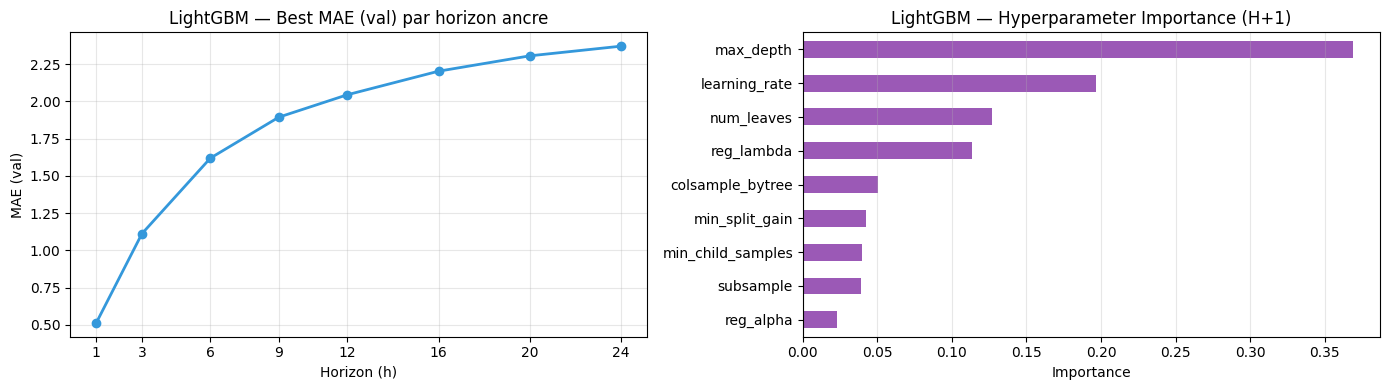

✅ best_lgb_params_per_horizon.json sauvegardé


In [7]:
# ── Visualisation Optuna LGB — agrégée sur les horizons ancres ────────────────
mae_per_h_lgb = []
for h in ANCHOR_HORIZONS:
    ck = load_json_ckpt(CKPT_LGB_OPT, h)
    if ck is not None:
        mae_per_h_lgb.append({"Horizon": h, "Best_MAE_val": ck["best_value"]})

df_lgb_opt = pd.DataFrame(mae_per_h_lgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df_lgb_opt["Horizon"], df_lgb_opt["Best_MAE_val"],
              "o-", color="#3498DB", lw=2)
axes[0].set(title="LightGBM — Best MAE (val) par horizon ancre",
             xlabel="Horizon (h)", ylabel="MAE (val)")
axes[0].grid(alpha=0.3)
axes[0].set_xticks(ANCHOR_HORIZONS)

# Importance des hyperparamètres pour H+1 (exemple représentatif)
try:
    study_h1 = joblib.load(ckpt_path_pkl(CKPT_LGB_OPT, 1, "study.pkl"))
    importances = optuna.importance.get_param_importances(study_h1)
    imp_df = pd.Series(importances).sort_values()
    imp_df.plot.barh(ax=axes[1], color="#9B59B6")
    axes[1].set(title="LightGBM — Hyperparameter Importance (H+1)", xlabel="Importance")
    axes[1].grid(axis="x", alpha=0.3)
except Exception:
    axes[1].text(0.5, 0.5, "Étude H+1 indisponible", ha="center", va="center")

plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "optuna_lgb.png", dpi=120, bbox_inches="tight")
plt.show()

# Sauvegarder un récapitulatif global (ancres + horizons propagés)
with open(ENSEMBLE_DIR / "best_lgb_params_per_horizon.json", "w") as f:
    json.dump(best_lgb_params_per_h, f, indent=2, default=str)
print("✅ best_lgb_params_per_horizon.json sauvegardé")

---
## 3. Optuna Tuning — CatBoost (horizons ancres uniquement)
> Mêmes principes : optimisation sur les `ANCHOR_HORIZONS`, checkpoint après chaque ancre
> dans `checkpoints/optuna_cb/h{H}.json`, puis propagation des params aux horizons
> non-ancres via l'ancre la plus proche.

In [8]:
def cb_objective_factory(pool_tr, pool_va, y_va_h):
    def objective(trial):
        params = {
            "iterations": trial.suggest_int("iterations", 300, 1000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "depth": trial.suggest_int("depth", 4, 10),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
            "random_strength": trial.suggest_float("random_strength", 0.0, 10.0),
            "border_count": trial.suggest_int("border_count", 32, 255),
            "loss_function": "RMSE",
            "eval_metric": "MAE",
            "random_seed": SEED,
            "verbose": 0,
            "task_type": "CPU",
            "thread_count": -1,
            "early_stopping_rounds": 30,
            "use_best_model": True,
        }
        model = CatBoostRegressor(**params)
        model.fit(pool_tr, eval_set=pool_va)
        preds = model.predict(pool_va)
        return mean_absolute_error(y_va_h, preds)

    return objective


best_cb_params_per_h = {}

print(f"🔍 Optuna CatBoost — horizons ancres {ANCHOR_HORIZONS} "
      f"(H+1: {N_TRIALS_H1} trials, autres: {N_TRIALS_OTHER} trials)...\n")

for h in ANCHOR_HORIZONS:
    tc = f"target24_h{h}"
    n_trials = n_trials_for(h)

    if is_done(CKPT_CB_OPT, h):
        ck = load_json_ckpt(CKPT_CB_OPT, h)
        best_cb_params_per_h[h] = ck["best_params"]
        print(f"⏭️  H+{h:<2d} déjà optimisé (MAE val={ck['best_value']:.4f}) — skip")
        continue

    t0 = time.time()
    try:
        mtr = get_masks(tc, "train")
        mva = get_masks(tc, "val")

        y_tr_h = df_train.loc[mtr, tc].values.astype(np.float32)
        y_va_h = df_val.loc[mva,   tc].values.astype(np.float32)

        pool_tr = Pool(df_train.loc[mtr, FEAT_CB].fillna(0), label=y_tr_h, cat_features=CAT_FEAT_CB)
        pool_va = Pool(df_val.loc[mva,   FEAT_CB].fillna(0), label=y_va_h, cat_features=CAT_FEAT_CB)

        objective = cb_objective_factory(pool_tr, pool_va, y_va_h)

        study = optuna.create_study(
            direction="minimize",
            sampler=TPESampler(seed=SEED),
            study_name=f"cb_pm25_h{h}"
        )
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

        best_params = dict(study.best_params)
        best_params.update({
            "loss_function": "RMSE",
            "eval_metric": "MAE",
            "random_seed": SEED,
            "verbose": 0,
            "task_type": "CPU",
            "thread_count": -1,
            "early_stopping_rounds": 30,
            "use_best_model": True,
        })

        best_cb_params_per_h[h] = best_params

        save_json_ckpt(CKPT_CB_OPT, h, {
            "horizon": h,
            "best_value": study.best_value,
            "best_params": best_params,
            "n_trials": len(study.trials),
            "elapsed_sec": round(time.time() - t0, 1),
        })
        joblib.dump(study, ckpt_path_pkl(CKPT_CB_OPT, h, "study.pkl"))

        del pool_tr, pool_va; gc.collect()

        print(f"✅ H+{h:<2d} ({n_trials} trials) MAE val={study.best_value:.4f}  "
              f"({time.time()-t0:.1f}s) — checkpoint sauvegardé")

    except (MemoryError, KeyboardInterrupt) as e:
        print(f"\n⚠️  Interruption à H+{h} ({type(e).__name__}). "
              f"Progrès des ancres précédentes sauvegardé. Relancez la cellule pour reprendre.")
        raise
    except Exception as e:
        print(f"\n❌ Erreur à H+{h}: {e}")
        traceback.print_exc()
        print("Le progrès précédent est sauvegardé. Corrigez puis relancez la cellule.")
        raise

print(f"\n🏁 Tuning CB terminé pour {len(best_cb_params_per_h)}/{len(ANCHOR_HORIZONS)} ancres.")

# ── Propager les params des ancres aux horizons non-ancres ───────────────────
for h in HORIZONS:
    if h not in best_cb_params_per_h:
        a = nearest_anchor(h)
        best_cb_params_per_h[h] = best_cb_params_per_h[a]
print("✅ Params propagés à tous les horizons H1–H24 (via ancre la plus proche)")

🔍 Optuna CatBoost — horizons ancres [1, 3, 6, 9, 12, 16, 20, 24] (H+1: 15 trials, autres: 12 trials)...

⏭️  H+1  déjà optimisé (MAE val=0.5157) — skip
⏭️  H+3  déjà optimisé (MAE val=1.1159) — skip
⏭️  H+6  déjà optimisé (MAE val=1.6301) — skip
⏭️  H+9  déjà optimisé (MAE val=1.9060) — skip
✅ H+12 (12 trials) MAE val=2.0643  (3036.0s) — checkpoint sauvegardé
✅ H+16 (12 trials) MAE val=2.1970  (2504.1s) — checkpoint sauvegardé
✅ H+20 (12 trials) MAE val=2.2968  (1829.1s) — checkpoint sauvegardé
✅ H+24 (12 trials) MAE val=2.3544  (1865.5s) — checkpoint sauvegardé

🏁 Tuning CB terminé pour 8/8 ancres.
✅ Params propagés à tous les horizons H1–H24 (via ancre la plus proche)


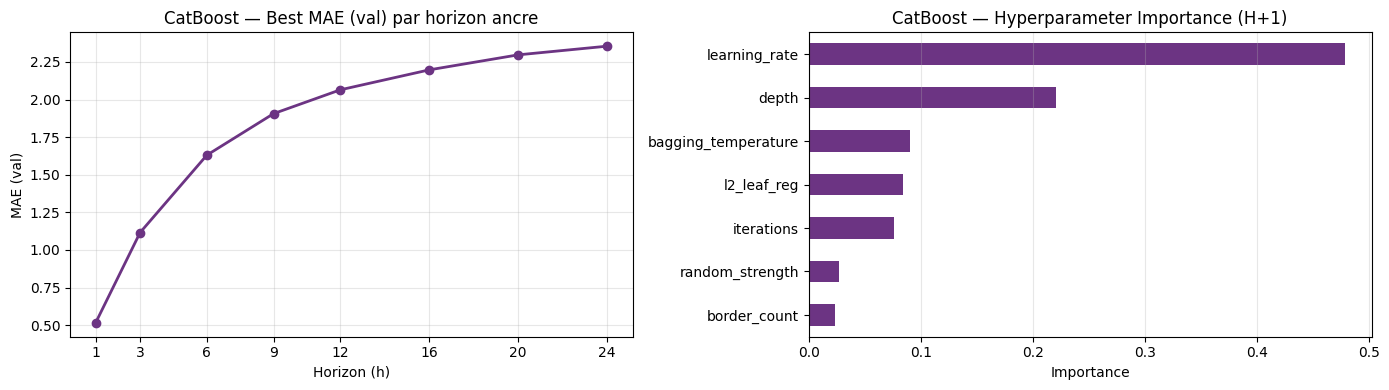

✅ best_cb_params_per_horizon.json sauvegardé


In [9]:
# ── Visualisation Optuna CB — agrégée sur les horizons ancres ─────────────────
mae_per_h_cb = []
for h in ANCHOR_HORIZONS:
    ck = load_json_ckpt(CKPT_CB_OPT, h)
    if ck is not None:
        mae_per_h_cb.append({"Horizon": h, "Best_MAE_val": ck["best_value"]})

df_cb_opt = pd.DataFrame(mae_per_h_cb)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df_cb_opt["Horizon"], df_cb_opt["Best_MAE_val"],
              "o-", color="#6C3483", lw=2)
axes[0].set(title="CatBoost — Best MAE (val) par horizon ancre",
             xlabel="Horizon (h)", ylabel="MAE (val)")
axes[0].grid(alpha=0.3)
axes[0].set_xticks(ANCHOR_HORIZONS)

try:
    study_h1_cb = joblib.load(ckpt_path_pkl(CKPT_CB_OPT, 1, "study.pkl"))
    importances_cb = optuna.importance.get_param_importances(study_h1_cb)
    imp_df_cb = pd.Series(importances_cb).sort_values()
    imp_df_cb.plot.barh(ax=axes[1], color="#6C3483")
    axes[1].set(title="CatBoost — Hyperparameter Importance (H+1)", xlabel="Importance")
    axes[1].grid(axis="x", alpha=0.3)
except Exception:
    axes[1].text(0.5, 0.5, "Étude H+1 indisponible", ha="center", va="center")

plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "optuna_cb.png", dpi=120, bbox_inches="tight")
plt.show()

with open(ENSEMBLE_DIR / "best_cb_params_per_horizon.json", "w") as f:
    json.dump(best_cb_params_per_h, f, indent=2, default=str)
print("✅ best_cb_params_per_horizon.json sauvegardé")

---
## 4. Retrain → H1–H24 (params de l'ancre la plus proche)
> Chaque horizon est ré-entraîné sur **sa propre target**, mais avec les hyperparamètres
> de l'ancre Optuna la plus proche (`nearest_anchor(h)`). Les horizons ancres utilisent
> directement leurs propres params optimisés.
>
> 💾 **Resumable** : chaque modèle entraîné (LGB et CB) est sauvegardé sur disque dès
> la fin de son horizon (`checkpoints/models_lgb/h{H}.txt`, `checkpoints/models_cb/h{H}.cbm`),
> ainsi que ses prédictions test (`checkpoints/preds/...`). Si le kernel plante, relancez
> la cellule : les horizons déjà entraînés sont rechargés depuis le disque sans
> ré-entraînement.

In [10]:
# ── LightGBM — tous horizons, params spécifiques par horizon ──────────────────
results_lgb_tuned = []
preds_lgb_tuned   = {}   # {h: (y_true, y_pred, mask_test)}
models_lgb        = {}   # {h: model}

for h in HORIZONS:
    tc = f"target24_h{h}"
    mtr = get_masks(tc, "train")
    mva = get_masks(tc, "val")
    mte = get_masks(tc, "test")

    model_path = ckpt_path_pkl(CKPT_LGB_MOD, h, "txt")
    preds_path = CKPT_PREDS / f"lgb_h{h}.npz"
    info_path  = ckpt_path_json(CKPT_LGB_MOD, h)

    # ── Resume : modèle + preds déjà sauvegardés ──
    if model_path.exists() and preds_path.exists() and info_path.exists():
        model = lgb.Booster(model_file=str(model_path))
        npz = np.load(preds_path)
        y_true, y_pred = npz["y_true"], npz["y_pred"]

        models_lgb[h] = model
        preds_lgb_tuned[h] = (y_true, y_pred, mte)

        info = load_json_ckpt(CKPT_LGB_MOD, h)
        results_lgb_tuned.append({
            "Horizon": h, "MAE": info["MAE"], "RMSE": info["RMSE"],
            "best_iter": info["best_iter"],
        })
        if h == 1:
            RESULTS.append(evaluate("LGB Tuned", y_true, y_pred))
        print(f"⏭️  LGB H+{h:<2d} déjà entraîné (MAE={info['MAE']:.3f}) — skip")
        continue

    try:
        params_h = best_lgb_params_per_h.get(h, best_lgb_params_per_h[1])
        src_anchor = h if h in ANCHOR_HORIZONS else nearest_anchor(h)

        ds_tr = lgb.Dataset(X_tr[mtr], label=df_train.loc[mtr, tc].values.astype(np.float32), free_raw_data=False)
        ds_va = lgb.Dataset(X_va[mva], label=df_val.loc[mva, tc].values.astype(np.float32),   reference=ds_tr, free_raw_data=False)

        model = lgb.train(
            params_h, ds_tr,
            num_boost_round=1000,
            valid_sets=[ds_va],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )
        y_pred = model.predict(X_te[mte])
        y_true = df_test.loc[mte, tc].values.astype(np.float32)

        mae_h  = round(mean_absolute_error(y_true, y_pred), 3)
        rmse_h = round(rmse(y_true, y_pred), 3)

        preds_lgb_tuned[h] = (y_true, y_pred, mte)
        models_lgb[h]      = model

        results_lgb_tuned.append({"Horizon": h, "MAE": mae_h, "RMSE": rmse_h, "best_iter": model.best_iteration})
        if h == 1:
            RESULTS.append(evaluate("LGB Tuned", y_true, y_pred))

        # ── Checkpoint immédiat : modèle + preds + infos ──
        model.save_model(str(model_path))
        np.savez(preds_path, y_true=y_true, y_pred=y_pred)
        save_json_ckpt(CKPT_LGB_MOD, h, {
            "horizon": h, "MAE": mae_h, "RMSE": rmse_h, "best_iter": int(model.best_iteration),
        })

        del ds_tr, ds_va; gc.collect()
        print(f"✓ LGB H+{h:<2d} (params ancre H+{src_anchor}) MAE={mae_h:.3f}  — checkpoint sauvegardé")

    except (MemoryError, KeyboardInterrupt) as e:
        print(f"\n⚠️  Interruption au retrain LGB H+{h} ({type(e).__name__}). "
              f"Modèles H+1..H+{h-1} sauvegardés. Relancez pour reprendre.")
        raise
    except Exception as e:
        print(f"\n❌ Erreur retrain LGB H+{h}: {e}")
        traceback.print_exc()
        raise

df_lgb_tuned = pd.DataFrame(results_lgb_tuned)
print(f"\n→ MAE moyen H1–H24 (LGB) : {df_lgb_tuned['MAE'].mean():.3f}")

✓ LGB H+1  (params ancre H+1) MAE=0.641  — checkpoint sauvegardé
✓ LGB H+2  (params ancre H+1) MAE=1.082  — checkpoint sauvegardé
✓ LGB H+3  (params ancre H+3) MAE=1.423  — checkpoint sauvegardé
✓ LGB H+4  (params ancre H+3) MAE=1.693  — checkpoint sauvegardé
✓ LGB H+5  (params ancre H+6) MAE=1.906  — checkpoint sauvegardé
✓ LGB H+6  (params ancre H+6) MAE=2.089  — checkpoint sauvegardé
✓ LGB H+7  (params ancre H+6) MAE=2.241  — checkpoint sauvegardé
✓ LGB H+8  (params ancre H+9) MAE=2.358  — checkpoint sauvegardé
✓ LGB H+9  (params ancre H+9) MAE=2.459  — checkpoint sauvegardé
✓ LGB H+10 (params ancre H+9) MAE=2.539  — checkpoint sauvegardé
✓ LGB H+11 (params ancre H+12) MAE=2.615  — checkpoint sauvegardé
✓ LGB H+12 (params ancre H+12) MAE=2.675  — checkpoint sauvegardé
✓ LGB H+13 (params ancre H+12) MAE=2.730  — checkpoint sauvegardé
✓ LGB H+14 (params ancre H+12) MAE=2.788  — checkpoint sauvegardé
✓ LGB H+15 (params ancre H+16) MAE=2.877  — checkpoint sauvegardé
✓ LGB H+16 (params a

In [11]:
# ── CatBoost — tous horizons, params spécifiques par horizon ──────────────────
results_cb_tuned = []
preds_cb_tuned   = {}
models_cb        = {}

for h in HORIZONS:
    tc = f"target24_h{h}"
    mtr = get_masks(tc, "train")
    mva = get_masks(tc, "val")
    mte = get_masks(tc, "test")

    model_path = ckpt_path_pkl(CKPT_CB_MOD, h, "cbm")
    preds_path = CKPT_PREDS / f"cb_h{h}.npz"
    info_path  = ckpt_path_json(CKPT_CB_MOD, h)

    if model_path.exists() and preds_path.exists() and info_path.exists():
        model = CatBoostRegressor()
        model.load_model(str(model_path))
        npz = np.load(preds_path)
        y_true, y_pred = npz["y_true"], npz["y_pred"]

        models_cb[h] = model
        preds_cb_tuned[h] = (y_true, y_pred, mte)

        info = load_json_ckpt(CKPT_CB_MOD, h)
        results_cb_tuned.append({
            "Horizon": h, "MAE": info["MAE"], "RMSE": info["RMSE"],
            "best_iter": info["best_iter"],
        })
        if h == 1:
            RESULTS.append(evaluate("CB Tuned", y_true, y_pred))
        print(f"⏭️  CB  H+{h:<2d} déjà entraîné (MAE={info['MAE']:.3f}) — skip")
        continue

    try:
        params_h = best_cb_params_per_h.get(h, best_cb_params_per_h[1])
        src_anchor = h if h in ANCHOR_HORIZONS else nearest_anchor(h)

        pool_tr = Pool(df_train.loc[mtr, FEAT_CB].fillna(0), label=df_train.loc[mtr, tc], cat_features=CAT_FEAT_CB)
        pool_va = Pool(df_val.loc[mva,   FEAT_CB].fillna(0), label=df_val.loc[mva, tc],   cat_features=CAT_FEAT_CB)
        pool_te = Pool(df_test.loc[mte,  FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)

        model = CatBoostRegressor(**params_h)
        model.fit(pool_tr, eval_set=pool_va)

        y_pred = model.predict(pool_te)
        y_true = df_test.loc[mte, tc].values

        mae_h  = round(mean_absolute_error(y_true, y_pred), 3)
        rmse_h = round(rmse(y_true, y_pred), 3)

        preds_cb_tuned[h] = (y_true, y_pred, mte)
        models_cb[h]      = model

        results_cb_tuned.append({"Horizon": h, "MAE": mae_h, "RMSE": rmse_h, "best_iter": model.get_best_iteration()})
        if h == 1:
            RESULTS.append(evaluate("CB Tuned", y_true, y_pred))

        # ── Checkpoint immédiat ──
        model.save_model(str(model_path))
        np.savez(preds_path, y_true=y_true, y_pred=y_pred)
        save_json_ckpt(CKPT_CB_MOD, h, {
            "horizon": h, "MAE": mae_h, "RMSE": rmse_h, "best_iter": int(model.get_best_iteration()),
        })

        del pool_tr, pool_va, pool_te; gc.collect()
        print(f"✓ CB  H+{h:<2d} (params ancre H+{src_anchor}) MAE={mae_h:.3f}  — checkpoint sauvegardé")

    except (MemoryError, KeyboardInterrupt) as e:
        print(f"\n⚠️  Interruption au retrain CB H+{h} ({type(e).__name__}). "
              f"Modèles H+1..H+{h-1} sauvegardés. Relancez pour reprendre.")
        raise
    except Exception as e:
        print(f"\n❌ Erreur retrain CB H+{h}: {e}")
        traceback.print_exc()
        raise

df_cb_tuned = pd.DataFrame(results_cb_tuned)
print(f"\n→ MAE moyen H1–H24 (CB) : {df_cb_tuned['MAE'].mean():.3f}")

✓ CB  H+1  (params ancre H+1) MAE=0.655  — checkpoint sauvegardé
✓ CB  H+2  (params ancre H+1) MAE=1.092  — checkpoint sauvegardé
✓ CB  H+3  (params ancre H+3) MAE=1.450  — checkpoint sauvegardé
✓ CB  H+4  (params ancre H+3) MAE=1.714  — checkpoint sauvegardé
✓ CB  H+5  (params ancre H+6) MAE=1.930  — checkpoint sauvegardé
✓ CB  H+6  (params ancre H+6) MAE=2.109  — checkpoint sauvegardé
✓ CB  H+7  (params ancre H+6) MAE=2.259  — checkpoint sauvegardé
✓ CB  H+8  (params ancre H+9) MAE=2.371  — checkpoint sauvegardé
✓ CB  H+9  (params ancre H+9) MAE=2.475  — checkpoint sauvegardé
✓ CB  H+10 (params ancre H+9) MAE=2.554  — checkpoint sauvegardé
✓ CB  H+11 (params ancre H+12) MAE=2.629  — checkpoint sauvegardé
✓ CB  H+12 (params ancre H+12) MAE=2.694  — checkpoint sauvegardé
✓ CB  H+13 (params ancre H+12) MAE=2.754  — checkpoint sauvegardé
✓ CB  H+14 (params ancre H+12) MAE=2.826  — checkpoint sauvegardé
✓ CB  H+15 (params ancre H+16) MAE=2.847  — checkpoint sauvegardé
✓ CB  H+16 (params a

---
## 5. Ensemble
### 5A — Weighted Blend (recherche des poids optimaux, par horizon)
> ⚠️ **Changement** : les poids optimaux LGB/CB sont calculés **séparément pour chaque
> horizon** (et non plus seulement sur H+1), car le meilleur compromis change selon
> l'horizon.

In [12]:
from scipy.optimize import minimize

def get_val_preds_lgb(h):
    tc  = f"target24_h{h}"
    mva = get_masks(tc, "val")
    return models_lgb[h].predict(X_va[mva]), df_val.loc[mva, tc].values

def get_val_preds_cb(h):
    tc  = f"target24_h{h}"
    mva = get_masks(tc, "val")
    pool = Pool(df_val.loc[mva, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
    return models_cb[h].predict(pool), df_val.loc[mva, tc].values

blend_weights_per_h = {}  # {h: [w_lgb, w_cb]}

for h in HORIZONS:
    val_preds_lgb_h, val_true_h = get_val_preds_lgb(h)
    val_preds_cb_h,  _          = get_val_preds_cb(h)

    def blend_mae(weights, vl=val_preds_lgb_h, vc=val_preds_cb_h, vt=val_true_h):
        w = np.array(weights)
        w = w / w.sum()
        blend = w[0] * vl + w[1] * vc
        return mean_absolute_error(vt, blend)

    res = minimize(blend_mae, x0=[0.5, 0.5], method="Nelder-Mead", options={"maxiter": 1000})
    w = np.array(res.x)
    w = w / w.sum()
    blend_weights_per_h[h] = w

    if h == 1:
        print(f"Poids optimaux H+{h}: LGB={w[0]:.3f}  CB={w[1]:.3f}  | MAE blend val={res.fun:.4f}")

# Pour compatibilité avec la sauvegarde finale (poids H+1 comme référence globale)
opt_w = blend_weights_per_h[1]

print(f"\n✅ Poids de blend calculés pour {len(blend_weights_per_h)} horizons.")
with open(ENSEMBLE_DIR / "blend_weights_per_horizon.json", "w") as f:
    json.dump({h: w.tolist() for h, w in blend_weights_per_h.items()}, f, indent=2)

Poids optimaux H+1: LGB=0.589  CB=0.411  | MAE blend val=0.5106

✅ Poids de blend calculés pour 24 horizons.


In [13]:
# ── Appliquer le blend sur TEST — tous horizons (poids spécifiques par horizon) ─
results_blend = []
preds_blend   = {}

for h in HORIZONS:
    y_true_lgb, y_pred_lgb, mte_lgb = preds_lgb_tuned[h]
    y_true_cb,  y_pred_cb,  mte_cb  = preds_cb_tuned[h]

    mask_both = mte_lgb & mte_cb
    tc = f"target24_h{h}"
    y_true = df_test.loc[mask_both, tc].values

    p_lgb = models_lgb[h].predict(X_te[mask_both])
    pool_te = Pool(df_test.loc[mask_both, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
    p_cb  = models_cb[h].predict(pool_te)

    w = blend_weights_per_h[h]
    y_blend = w[0] * p_lgb + w[1] * p_cb
    preds_blend[h] = (y_true, y_blend)

    results_blend.append({
        "Horizon": h,
        "MAE":  round(mean_absolute_error(y_true, y_blend), 3),
        "RMSE": round(rmse(y_true, y_blend), 3),
        "w_lgb": round(w[0], 3),
        "w_cb":  round(w[1], 3),
    })
    if h == 1:
        RESULTS.append(evaluate("Blend LGB+CB", y_true, y_blend))

df_blend = pd.DataFrame(results_blend)
display(df_blend)
print(f"\n→ MAE moyen H1–H24 : {df_blend['MAE'].mean():.3f}")

,Horizon,MAE,RMSE,w_lgb,w_cb
0,1,0.6420,1.3630,0.5890,0.4110
1,2,1.0800,2.0570,0.4600,0.5400
2,3,1.4230,2.6320,0.5610,0.4390
3,4,1.6900,3.0400,0.5460,0.4540
4,5,1.9040,3.3700,0.5140,0.4860
5,6,2.0820,3.6450,0.6170,0.3830
6,7,2.2320,3.8650,0.6720,0.3280
7,8,2.3470,4.0360,0.6320,0.3680
8,9,2.4510,4.1880,0.6350,0.3650
9,10,2.5300,4.3040,0.6240,0.3760



→ MAE moyen H1–H24 : 2.473


### 5B — Stacking (méta-modèle Ridge)

In [14]:
# ── Stacking : méta-features = prédictions OOF ────────────────────────────────
# On utilise val comme méta-train, test comme méta-test

results_stack = []
preds_stack   = {}

for h in HORIZONS:
    tc  = f"target24_h{h}"
    mva = get_masks(tc, "val")
    mte = get_masks(tc, "test")

    p_lgb_va = models_lgb[h].predict(X_va[mva])
    cb_va_pool = Pool(df_val.loc[mva, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
    p_cb_va  = models_cb[h].predict(cb_va_pool)

    X_meta_va = np.column_stack([p_lgb_va, p_cb_va])
    y_meta_va = df_val.loc[mva, tc].values

    p_lgb_te = models_lgb[h].predict(X_te[mte])
    cb_te_pool = Pool(df_test.loc[mte, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
    p_cb_te  = models_cb[h].predict(cb_te_pool)

    X_meta_te = np.column_stack([p_lgb_te, p_cb_te])
    y_meta_te = df_test.loc[mte, tc].values

    meta = Ridge(alpha=1.0)
    meta.fit(X_meta_va, y_meta_va)
    y_stack = meta.predict(X_meta_te)

    preds_stack[h] = (y_meta_te, y_stack)

    results_stack.append({
        "Horizon": h,
        "MAE":  round(mean_absolute_error(y_meta_te, y_stack), 3),
        "RMSE": round(rmse(y_meta_te, y_stack), 3),
        "LGB_w": round(meta.coef_[0], 3),
        "CB_w":  round(meta.coef_[1], 3),
    })
    if h == 1:
        RESULTS.append(evaluate("Stack Ridge", y_meta_te, y_stack))

df_stack = pd.DataFrame(results_stack)
display(df_stack)
print(f"\n→ MAE moyen H1–H24 : {df_stack['MAE'].mean():.3f}")

,Horizon,MAE,RMSE,LGB_w,CB_w
0,1,0.6450,1.3820,0.4780,0.5160
1,2,1.0810,2.0760,0.3380,0.6550
2,3,1.4220,2.6450,0.5350,0.4590
3,4,1.6850,3.0520,0.5440,0.4490
4,5,1.8960,3.3890,0.4790,0.5090
5,6,2.0740,3.6740,0.5550,0.4270
6,7,2.2220,3.8990,0.6030,0.3720
7,8,2.3350,4.0730,0.5160,0.4530
8,9,2.4390,4.2340,0.5760,0.3850
9,10,2.5190,4.3630,0.5880,0.3540



→ MAE moyen H1–H24 : 2.472


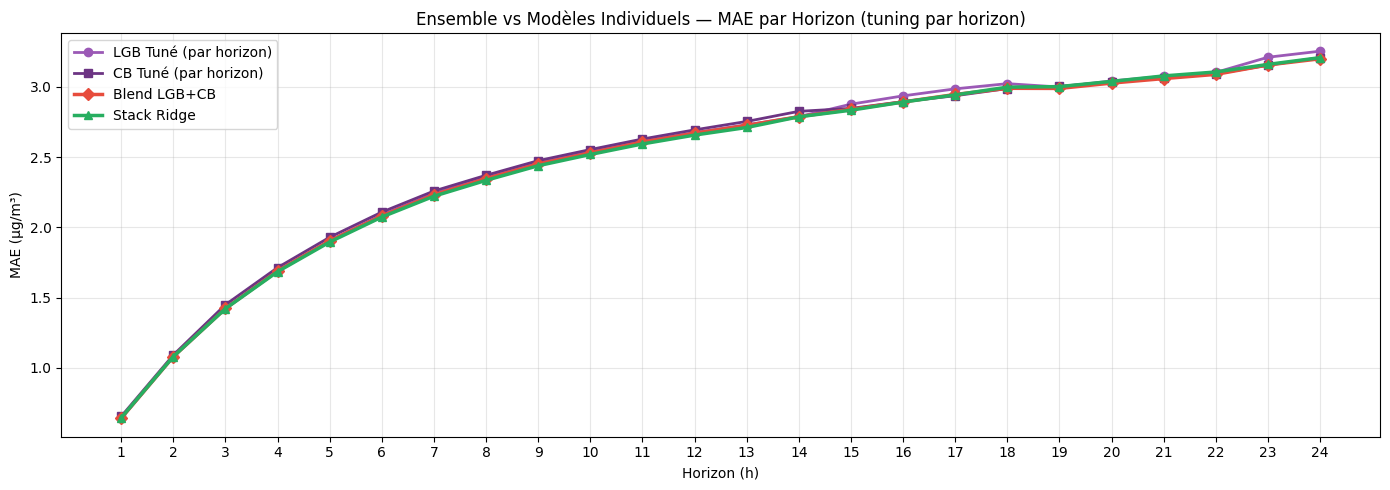

In [15]:
# ── Comparaison : LGB tuné vs CB tuné vs Blend vs Stack ──────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_lgb_tuned["Horizon"], df_lgb_tuned["MAE"],
        "o-", color="#9B59B6", lw=2, label="LGB Tuné (par horizon)")
ax.plot(df_cb_tuned["Horizon"],  df_cb_tuned["MAE"],
        "s-", color="#6C3483", lw=2, label="CB Tuné (par horizon)")
ax.plot(df_blend["Horizon"],     df_blend["MAE"],
        "D-", color="#E74C3C", lw=2.5, label="Blend LGB+CB")
ax.plot(df_stack["Horizon"],     df_stack["MAE"],
        "^-", color="#27AE60", lw=2.5, label="Stack Ridge")

ax.set(title="Ensemble vs Modèles Individuels — MAE par Horizon (tuning par horizon)",
       xlabel="Horizon (h)", ylabel="MAE (µg/m³)")
ax.legend(); ax.grid(alpha=0.3)
ax.set_xticks(HORIZONS)
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# ── Leaderboard final (H+1) ────────────────────────────────────────────────────
df_lb = pd.DataFrame(RESULTS).sort_values("MAE")
df_lb.index = range(1, len(df_lb)+1)
display(df_lb.style
    .background_gradient(subset=["MAE","RMSE"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2"], cmap="RdYlGn")
    .format({"MAE":"{:.4f}","RMSE":"{:.4f}","SMAPE":"{:.2f}%","R2":"{:.4f}"})
)
df_lb.to_csv(ENSEMBLE_DIR / "leaderboard_ensemble.csv", index=False)

,Model,MAE,RMSE,SMAPE,R2,N
1,LGB Tuned,0.6411,1.3284,6.58%,0.9587,131550
2,Blend LGB+CB,0.6419,1.3626,6.57%,0.9565,131550
3,Stack Ridge,0.6447,1.3824,6.58%,0.9553,131550
4,CB Tuned,0.6546,1.4511,6.66%,0.9507,131550


---
## 6. Analyse des Erreurs par Ville & par Heure

In [17]:
# ── Stocker les prédictions du meilleur modèle (Blend) dans df_test ───────────
df_test = df_test.copy()

mte_h1 = get_masks(TARGET_H1, "test")
p_lgb_all = models_lgb[1].predict(X_te[mte_h1])
cb_te_all  = Pool(df_test.loc[mte_h1, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
p_cb_all   = models_cb[1].predict(cb_te_all)
w1 = blend_weights_per_h[1]
blend_all  = w1[0] * p_lgb_all + w1[1] * p_cb_all

df_test.loc[mte_h1, "pred_blend_h1"] = blend_all
df_test.loc[mte_h1, "error_h1"]      = np.abs(blend_all - df_test.loc[mte_h1, TARGET_H1].values)
df_test.loc[mte_h1, "bias_h1"]       = blend_all - df_test.loc[mte_h1, TARGET_H1].values

print(f"Rows avec prédiction : {mte_h1.sum():,}")

Rows avec prédiction : 131,550


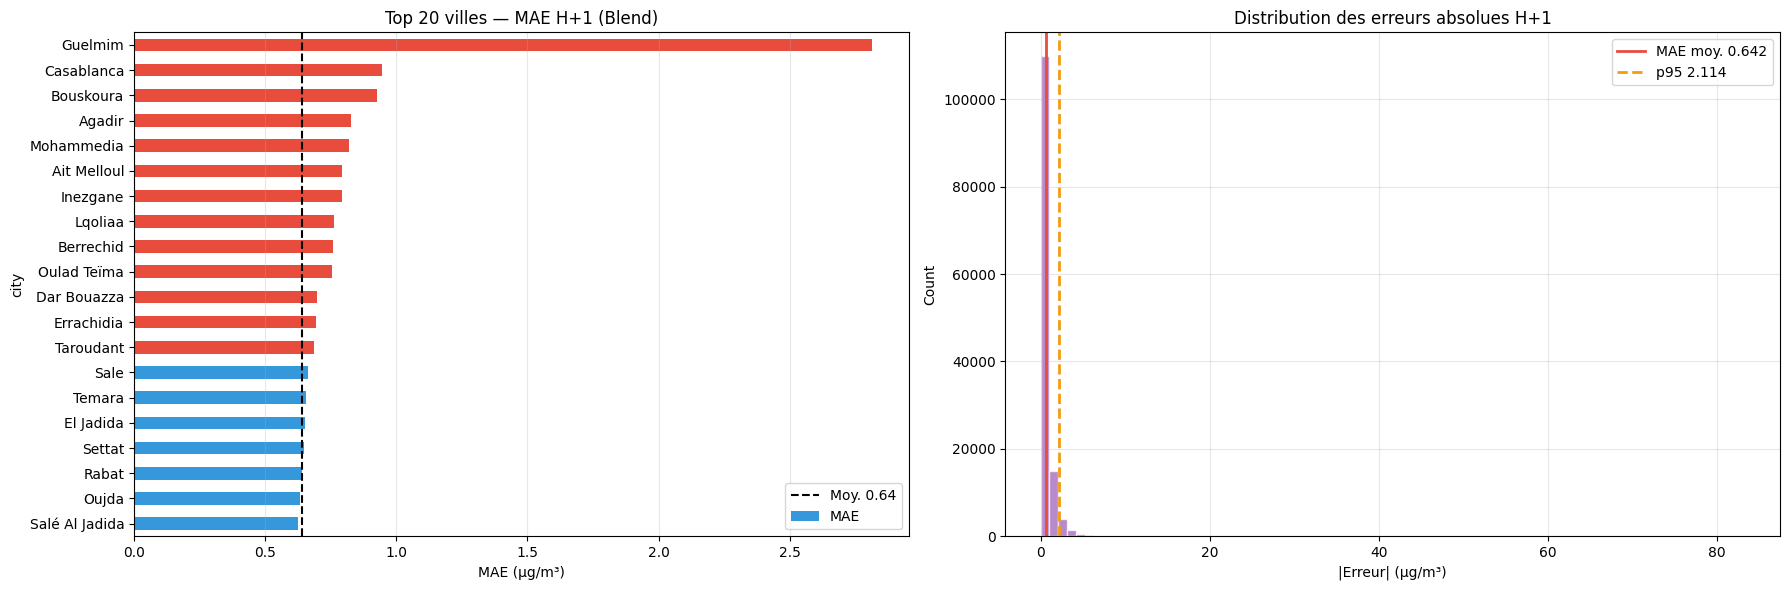

,MAE,Std,Max
city,,,
Guelmim,2.8125,5.9355,83.3335
Casablanca,0.9472,1.2532,12.4209
Bouskoura,0.9260,1.0877,11.8168
Agadir,0.8289,1.0068,9.5365
Mohammedia,0.8179,0.9968,10.3624
Ait Melloul,0.7933,1.0637,23.3594
Inezgane,0.7926,1.0637,23.3488
Lqoliaa,0.7638,1.0368,20.3473
Berrechid,0.7577,0.8529,7.5556


In [18]:
# ── MAE par ville ─────────────────────────────────────────────────────────────
city_errors = (
    df_test.dropna(subset=["error_h1"])
    .groupby("city")["error_h1"]
    .agg(["mean", "std", "max"])
    .rename(columns={"mean":"MAE","std":"Std","max":"Max"})
    .sort_values("MAE", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = ["#E74C3C" if v > city_errors["MAE"].quantile(0.75) else "#3498DB"
          for v in city_errors["MAE"].head(20)]
city_errors["MAE"].head(20).sort_values().plot.barh(
    ax=axes[0], color=colors[::-1]
)
axes[0].set(title="Top 20 villes — MAE H+1 (Blend)", xlabel="MAE (µg/m³)")
axes[0].axvline(city_errors["MAE"].mean(), color="black", lw=1.5,
                linestyle="--", label=f"Moy. {city_errors['MAE'].mean():.2f}")
axes[0].legend(); axes[0].grid(axis="x", alpha=0.3)

axes[1].hist(df_test["error_h1"].dropna(), bins=80, color="#9B59B6", alpha=0.7, edgecolor="white")
axes[1].axvline(df_test["error_h1"].dropna().mean(), color="#E74C3C",
                lw=2, label=f"MAE moy. {df_test['error_h1'].dropna().mean():.3f}")
axes[1].axvline(df_test["error_h1"].dropna().quantile(0.95), color="#F39C12",
                lw=2, linestyle="--", label=f"p95 {df_test['error_h1'].dropna().quantile(0.95):.3f}")
axes[1].set(title="Distribution des erreurs absolues H+1", xlabel="|Erreur| (µg/m³)", ylabel="Count")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "error_by_city.png", dpi=150, bbox_inches="tight")
plt.show()

display(city_errors.head(10))

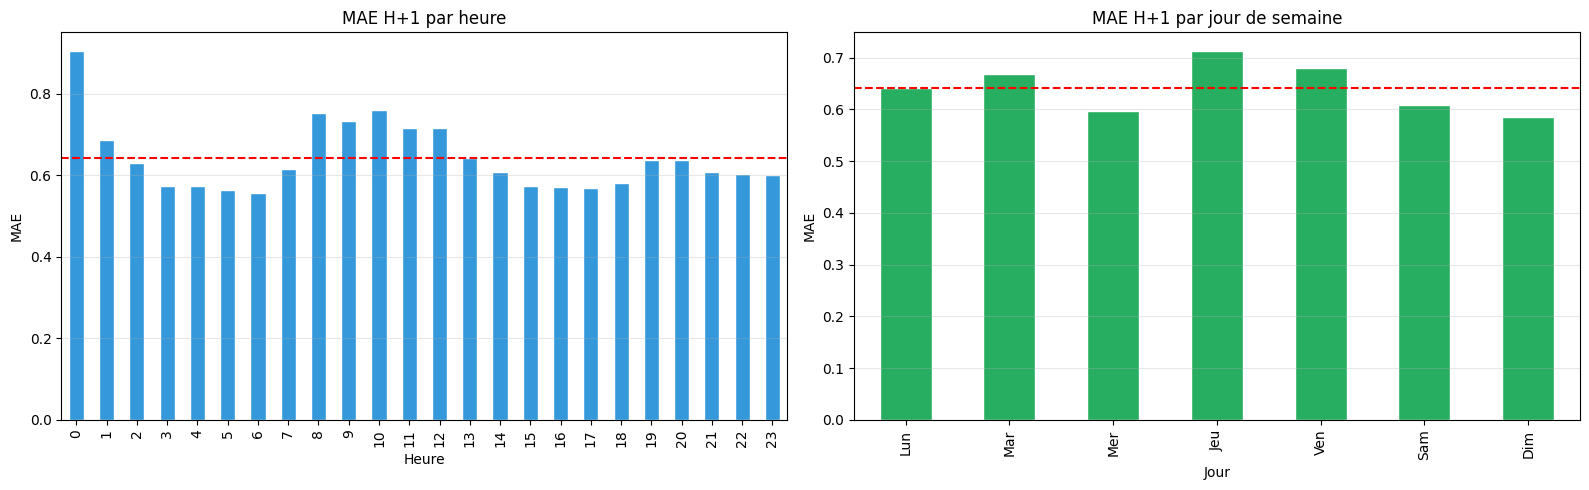

In [19]:
# ── MAE par heure de la journée & jour de semaine ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hour_err = df_test.dropna(subset=["error_h1"]).groupby("hour")["error_h1"].mean()
dow_err  = df_test.dropna(subset=["error_h1"]).groupby("dayofweek")["error_h1"].mean()

hour_err.plot(ax=axes[0], kind="bar", color="#3498DB", edgecolor="white")
axes[0].set(title="MAE H+1 par heure", xlabel="Heure", ylabel="MAE")
axes[0].axhline(hour_err.mean(), color="red", lw=1.5, linestyle="--")
axes[0].grid(axis="y", alpha=0.3)

dow_names = ["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"]
dow_err.index = dow_names
dow_err.plot(ax=axes[1], kind="bar", color="#27AE60", edgecolor="white")
axes[1].set(title="MAE H+1 par jour de semaine", xlabel="Jour", ylabel="MAE")
axes[1].axhline(dow_err.mean(), color="red", lw=1.5, linestyle="--")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "error_by_hour_dow.png", dpi=150, bbox_inches="tight")
plt.show()

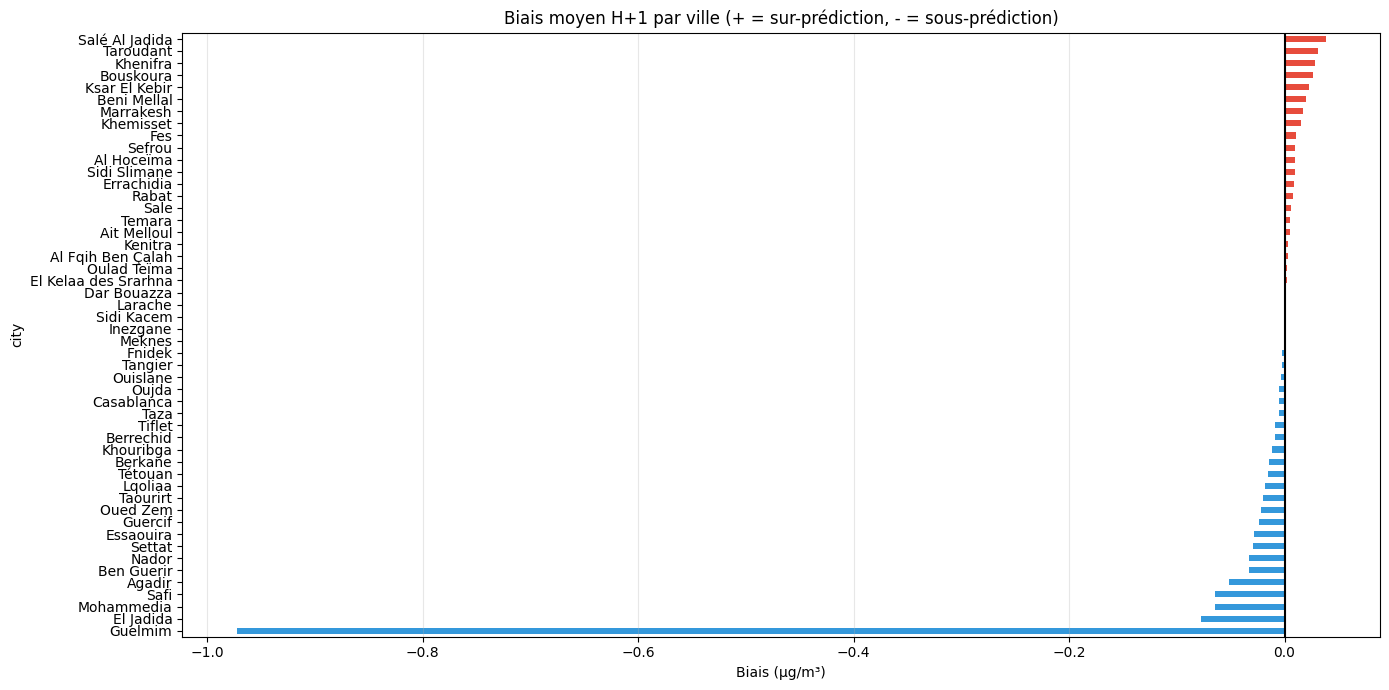

In [20]:
# ── Bias map : sur-prédiction vs sous-prédiction par ville ────────────────────
bias_city = (
    df_test.dropna(subset=["bias_h1"])
    .groupby("city")["bias_h1"].mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(14, 7))
colors = ["#E74C3C" if v > 0 else "#3498DB" for v in bias_city]
bias_city.plot.barh(ax=ax, color=colors)
ax.axvline(0, color="black", lw=1.5)
ax.set(title="Biais moyen H+1 par ville (+ = sur-prédiction, - = sous-prédiction)",
       xlabel="Biais (µg/m³)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "bias_by_city.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Analyse des Pics Extrêmes (p99)

Seuils PM2.5 — p75: 12.3  p90: 17.1  p99: 30.9 µg/m³


,MAE_mean,MAE_std,N
pm25_bin,,,
Normal (<p75),0.4499,0.5531,99069
Élevé (p75-p90),0.8758,0.9277,19371
Très élevé (p90-p99),1.3794,1.5070,11797
Extrême (>p99),5.0486,7.7909,1313


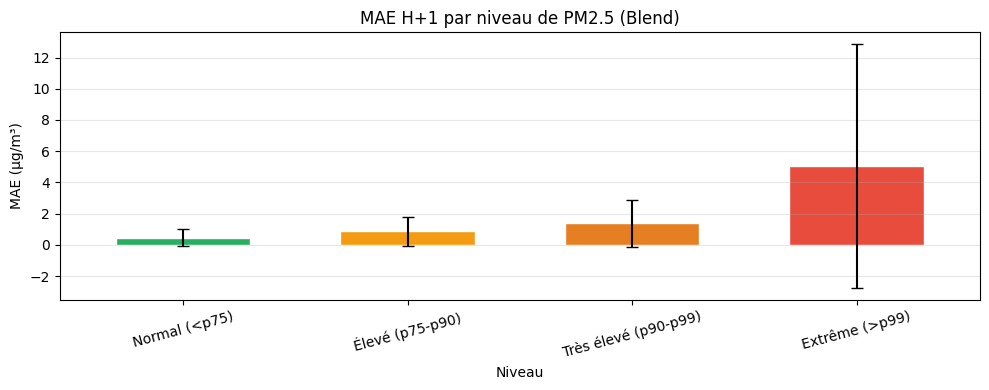

In [21]:
# ── Performance sur les valeurs extrêmes ──────────────────────────────────────
p99 = df_test[TARGET_H1].quantile(0.99)
p90 = df_test[TARGET_H1].quantile(0.90)
p75 = df_test[TARGET_H1].quantile(0.75)

print(f"Seuils PM2.5 — p75: {p75:.1f}  p90: {p90:.1f}  p99: {p99:.1f} µg/m³")

bins   = [0, p75, p90, p99, df_test[TARGET_H1].max() + 1]
labels = ["Normal (<p75)", "Élevé (p75-p90)", "Très élevé (p90-p99)", "Extrême (>p99)"]

df_test["pm25_bin"] = pd.cut(
    df_test[TARGET_H1], bins=bins, labels=labels, include_lowest=True
)

extreme_perf = (
    df_test.dropna(subset=["error_h1", "pm25_bin"])
    .groupby("pm25_bin", observed=True)["error_h1"]
    .agg(["mean","std","count"])
    .rename(columns={"mean":"MAE_mean","std":"MAE_std","count":"N"})
)
display(extreme_perf)

fig, ax = plt.subplots(figsize=(10, 4))
extreme_perf["MAE_mean"].plot.bar(
    ax=ax,
    color=["#27AE60","#F39C12","#E67E22","#E74C3C"],
    edgecolor="white", width=0.6
)
ax.errorbar(
    x=range(len(extreme_perf)),
    y=extreme_perf["MAE_mean"],
    yerr=extreme_perf["MAE_std"],
    fmt="none", color="black", capsize=4
)
ax.set(title="MAE H+1 par niveau de PM2.5 (Blend)",
       xlabel="Niveau", ylabel="MAE (µg/m³)")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "error_by_pm25_level.png", dpi=150, bbox_inches="tight")
plt.show()

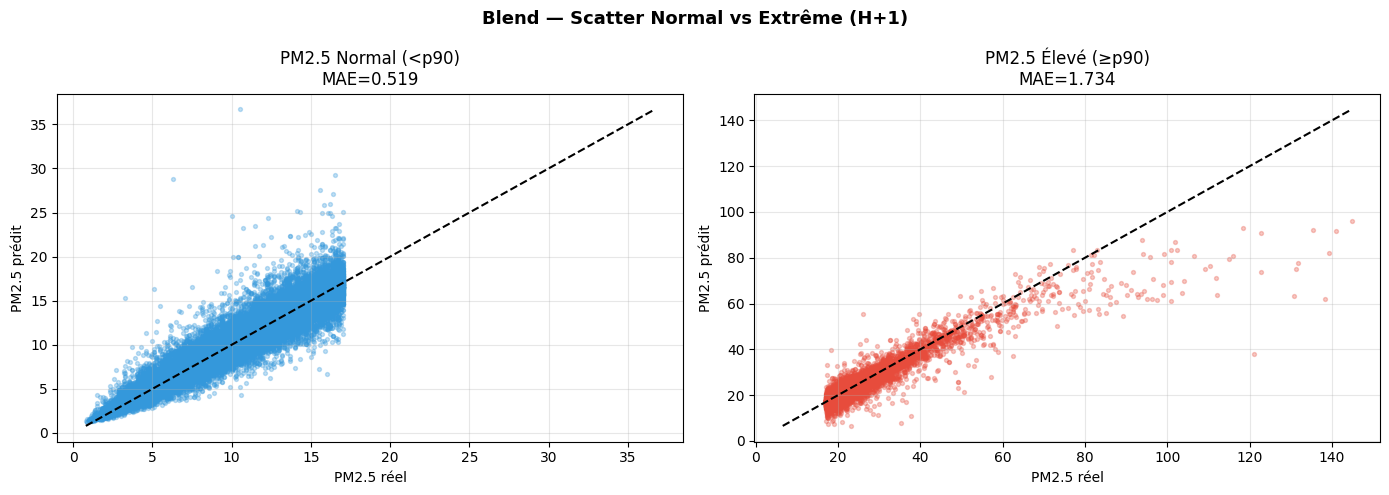

In [22]:
# ── Scatter extremes ──────────────────────────────────────────────────────────
df_extreme = df_test[df_test[TARGET_H1] >= p90].dropna(subset=["pred_blend_h1"])
df_normal  = df_test[df_test[TARGET_H1] <  p90].dropna(subset=["pred_blend_h1"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_sub, title, color in zip(
    axes,
    [df_normal, df_extreme],
    ["PM2.5 Normal (<p90)", "PM2.5 Élevé (≥p90)"],
    ["#3498DB", "#E74C3C"]
):
    ax.scatter(df_sub[TARGET_H1].values,
               df_sub["pred_blend_h1"].values,
               alpha=0.3, s=8, color=color)
    lim_min = min(df_sub[TARGET_H1].min(), df_sub["pred_blend_h1"].min())
    lim_max = max(df_sub[TARGET_H1].max(), df_sub["pred_blend_h1"].max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", lw=1.5)
    mae_sub = mean_absolute_error(df_sub[TARGET_H1], df_sub["pred_blend_h1"])
    ax.set(title=f"{title}\nMAE={mae_sub:.3f}",
           xlabel="PM2.5 réel", ylabel="PM2.5 prédit")
    ax.grid(alpha=0.3)

plt.suptitle("Blend — Scatter Normal vs Extrême (H+1)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "scatter_extreme_vs_normal.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Pipeline d'Inférence Temps Réel
> **Entrée** : nom de ville + heure courante T
> **Sortie** : prédictions PM2.5 pour T+1 → T+24 (le blend utilise désormais les
> poids spécifiques à chaque horizon `blend_weights_per_h[h]`).

In [23]:
class PM25Predictor:
    """
    Pipeline d'inférence temps réel PM2.5.
    Utilise les modèles LGB + CB tunés par horizon + blend (poids par horizon).
    """

    def __init__(self, models_lgb, models_cb, blend_weights_per_h,
                 feat_num, feat_cb, cat_feat_cb, label_encoder):
        self.models_lgb     = models_lgb       # dict {h: lgb_model}
        self.models_cb      = models_cb        # dict {h: cb_model}
        self.blend_w_per_h  = blend_weights_per_h  # dict {h: [w_lgb, w_cb]}
        self.feat_num       = feat_num
        self.feat_cb        = feat_cb
        self.cat_feat_cb    = cat_feat_cb
        self.le             = label_encoder

    def _build_row(self, city: str, dt: pd.Timestamp,
                   historical_df: pd.DataFrame) -> pd.DataFrame:
        """
        Construit une ligne de features pour (city, dt) à partir de
        l'historique passé (doit contenir au moins 336h de données).
        """
        city_hist = historical_df[
            (historical_df["city"] == city) &
            (historical_df["datetime"] < dt)
        ].sort_values("datetime").tail(336)

        if len(city_hist) < 24:
            raise ValueError(f"Pas assez d'historique pour {city} à {dt}")

        row = {"city": city, "datetime": dt}

        # Features temporelles
        row["hour"]      = dt.hour
        row["dayofweek"] = dt.dayofweek
        row["month"]     = dt.month
        row["day"]       = dt.day
        row["weekofyear"]= dt.isocalendar()[1]
        row["hour_sin"]  = np.sin(2 * np.pi * dt.hour / 24)
        row["hour_cos"]  = np.cos(2 * np.pi * dt.hour / 24)
        row["dow_sin"]   = np.sin(2 * np.pi * dt.dayofweek / 7)
        row["dow_cos"]   = np.cos(2 * np.pi * dt.dayofweek / 7)
        row["month_sin"] = np.sin(2 * np.pi * dt.month / 12)
        row["month_cos"] = np.cos(2 * np.pi * dt.month / 12)

        # Coordonnées (depuis l'historique)
        row["lat"] = city_hist["lat"].iloc[-1]
        row["lon"] = city_hist["lon"].iloc[-1]

        # Lags PM2.5
        pm25_series = city_hist.set_index("datetime")["pm2_5"]
        for lag in [1,2,3,6,12,24,48,72,168,336]:
            lag_dt = dt - pd.Timedelta(hours=lag)
            row[f"pm25_lag_{lag}h"] = pm25_series.get(lag_dt, np.nan)

        # Rolling features (sur les 168 dernières heures)
        pm25_vals = pm25_series.values
        for w in [3,6,12,24,48,72,168]:
            slice_w = pm25_vals[-w:] if len(pm25_vals) >= w else pm25_vals
            row[f"roll_mean_{w}h"] = np.nanmean(slice_w)
            row[f"roll_std_{w}h"]  = np.nanstd(slice_w)

        # Encodage ville
        row["city_enc"] = self.le.transform([city])[0]

        return pd.DataFrame([row])

    def predict(self, city: str, dt: pd.Timestamp,
                 historical_df: pd.DataFrame) -> pd.DataFrame:
        """Retourne un DataFrame avec colonnes [datetime, horizon, pm25_pred]
        pour T+1 → T+24, en utilisant le blend LGB+CB avec poids par horizon."""
        row = self._build_row(city, dt, historical_df)

        x_num = row[self.feat_num].astype(float).values.astype(np.float32)
        x_cb  = row[self.feat_cb].fillna(0)

        results = []
        for h in range(1, 25):
            p_lgb = self.models_lgb[h].predict(x_num)[0]

            pool_cb = Pool(x_cb, cat_features=self.cat_feat_cb)
            p_cb = self.models_cb[h].predict(pool_cb)[0]

            w = self.blend_w_per_h.get(h, [0.5, 0.5])
            p_blend = w[0] * p_lgb + w[1] * p_cb

            results.append({
                "datetime": dt + pd.Timedelta(hours=h),
                "horizon": h,
                "pm25_pred": p_blend,
                "pm25_pred_lgb": p_lgb,
                "pm25_pred_cb": p_cb,
            })

        return pd.DataFrame(results)


# ── Instanciation du predictor ──
predictor = PM25Predictor(
    models_lgb=models_lgb,
    models_cb=models_cb,
    blend_weights_per_h=blend_weights_per_h,
    feat_num=FEAT_NUM,
    feat_cb=FEAT_CB,
    cat_feat_cb=CAT_FEAT_CB,
    label_encoder=le,
)
print("✅ Predictor prêt")

✅ Predictor prêt


In [24]:
# ── Test de l'inférence sur Casablanca ────────────────────────────────────────
CITY_INF = "Casablanca"
T_now = df_test[df_test["city"] == CITY_INF]["datetime"].max() - pd.Timedelta(hours=24)

historical_df = df.copy()

print(f"🔮 Inférence pour {CITY_INF} à T = {T_now}")
forecast = predictor.predict(CITY_INF, T_now, historical_df)
display(forecast)

ground_truth = df_test[
    (df_test["city"] == CITY_INF) &
    (df_test["datetime"] > T_now) &
    (df_test["datetime"] <= T_now + pd.Timedelta(hours=24))
][["datetime","pm2_5"]].sort_values("datetime")

if len(ground_truth) > 0:
    forecast_merged = forecast.merge(
        ground_truth.rename(columns={"pm2_5":"pm25_real"}),
        on="datetime", how="left"
    )
    mae_inf = mean_absolute_error(
        forecast_merged["pm25_real"].dropna(),
        forecast_merged.loc[forecast_merged["pm25_real"].notna(), "pm25_pred"]
    )
    print(f"\nMAE inférence vs réel : {mae_inf:.3f} µg/m³")

🔮 Inférence pour Casablanca à T = 2026-06-07 22:00:00


KeyError: "['roll_min_3h', 'roll_max_3h', 'roll_min_6h', 'roll_max_6h', 'roll_min_12h', 'roll_max_12h', 'roll_min_24h', 'roll_max_24h', 'roll_min_48h', 'roll_max_48h', 'roll_min_72h', 'roll_max_72h', 'roll_min_168h', 'roll_max_168h', 'temp_change_1h', 'humidity_change_1h', 'pm25_change_1h', 'pm25_ewm_6h', 'pm25_ewm_24h', 'pm25_city_hour_mean', 'pm25_city_dow_mean', 'pm25_city_month_mean', 'temp_humidity', 'temp_wind', 'humidity_wind', 'pm25_change_3h', 'pm25_change_6h', 'pm25_change_24h'] not in index"

In [ ]:
# ── Visualisation inférence ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(forecast["datetime"], forecast["pm25_pred"],
        "o--", color="#9B59B6", lw=2, markersize=6, label="Prédiction Blend H+1→H+24")

ax.fill_between(
    forecast["datetime"],
    forecast["pm25_pred"] * 0.88,
    forecast["pm25_pred"] * 1.12,
    alpha=0.15, color="#9B59B6", label="±12% intervalle"
)

if len(ground_truth) > 0:
    ax.plot(ground_truth["datetime"], ground_truth["pm2_5"],
            "s-", color="#2C3E50", lw=2, markersize=5, label="Réel")

last_known = historical_df[
    (historical_df["city"] == CITY_INF) &
    (historical_df["datetime"] == T_now)
]["pm2_5"].values
if len(last_known) > 0:
    ax.axhline(last_known[0], color="gray", lw=1, linestyle=":",
               label=f"Valeur à T={last_known[0]:.1f} µg/m³")

ax.set(
    title=f"{CITY_INF} — Forecast PM2.5 T+1 → T+24\n(T = {T_now.strftime('%Y-%m-%d %H:00')})",
    xlabel="Datetime", ylabel="PM2.5 (µg/m³)"
)
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / f"inference_{CITY_INF.lower()}_{T_now.strftime('%Y%m%d_%H')}.png",
            dpi=150, bbox_inches="tight")
plt.show()

---
## 9. Sauvegarde Modèles Finaux

In [ ]:
# ── Sauvegarder tous les modèles LGB (copie finale, hors checkpoints) ─────────
lgb_dir = ENSEMBLE_DIR / "models_lgb"
lgb_dir.mkdir(exist_ok=True)
for h, model in models_lgb.items():
    model.save_model(str(lgb_dir / f"lgb_h{h}.txt"))
print(f"✅ {len(models_lgb)} modèles LGB sauvegardés → {lgb_dir}")

# ── Sauvegarder tous les modèles CatBoost ─────────────────────────────────────
cb_dir = ENSEMBLE_DIR / "models_cb"
cb_dir.mkdir(exist_ok=True)
for h, model in models_cb.items():
    model.save_model(str(cb_dir / f"cb_h{h}.cbm"))
print(f"✅ {len(models_cb)} modèles CB sauvegardés → {cb_dir}")

# ── Sauvegarder le LabelEncoder et les poids de blend par horizon ─────────────
joblib.dump(le, ENSEMBLE_DIR / "label_encoder.pkl")
np.save(ENSEMBLE_DIR / "blend_weights_h1.npy", opt_w)  # compat: poids H+1
with open(ENSEMBLE_DIR / "blend_weights_per_horizon.json", "w") as f:
    json.dump({h: w.tolist() for h, w in blend_weights_per_h.items()}, f, indent=2)

# ── Sauvegarder les meilleurs hyperparamètres par horizon ─────────────────────
with open(ENSEMBLE_DIR / "best_lgb_params_per_horizon.json", "w") as f:
    json.dump(best_lgb_params_per_h, f, indent=2, default=str)
with open(ENSEMBLE_DIR / "best_cb_params_per_horizon.json", "w") as f:
    json.dump(best_cb_params_per_h, f, indent=2, default=str)

# ── Sauvegarder les listes de features ────────────────────────────────────────
with open(ENSEMBLE_DIR / "feat_num.json", "w") as f:
    json.dump(FEAT_NUM, f)
with open(ENSEMBLE_DIR / "feat_cb.json", "w") as f:
    json.dump(FEAT_CB, f)

print("\n📁 Contenu ensemble_outputs:")
for p in sorted(ENSEMBLE_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(ENSEMBLE_DIR)}")

In [ ]:
# ── Résumé final ──────────────────────────────────────────────────────────────
print("\n" + "═" * 65)
print("  🏆  RÉSUMÉ FINAL — ENSEMBLE (tuning par horizon)")
print("═" * 65)

summary = pd.DataFrame({
    "Modèle":        ["LGB Tuné", "CB Tuné", "Blend LGB+CB", "Stack Ridge"],
    "MAE_mean":      [
        df_lgb_tuned["MAE"].mean().round(3),
        df_cb_tuned["MAE"].mean().round(3),
        df_blend["MAE"].mean().round(3),
        df_stack["MAE"].mean().round(3),
    ],
    "MAE_H1":  [
        df_lgb_tuned.iloc[0]["MAE"],
        df_cb_tuned.iloc[0]["MAE"],
        df_blend.iloc[0]["MAE"],
        df_stack.iloc[0]["MAE"],
    ],
    "MAE_H12": [
        df_lgb_tuned.iloc[11]["MAE"],
        df_cb_tuned.iloc[11]["MAE"],
        df_blend.iloc[11]["MAE"],
        df_stack.iloc[11]["MAE"],
    ],
    "MAE_H24": [
        df_lgb_tuned.iloc[23]["MAE"],
        df_cb_tuned.iloc[23]["MAE"],
        df_blend.iloc[23]["MAE"],
        df_stack.iloc[23]["MAE"],
    ],
}).sort_values("MAE_mean")

display(summary.style.background_gradient(
    subset=["MAE_mean","MAE_H1","MAE_H12","MAE_H24"], cmap="RdYlGn_r"
))

summary.to_csv(ENSEMBLE_DIR / "ensemble_summary.csv", index=False)
print(f"\n✅ Tout sauvegardé dans {ENSEMBLE_DIR}")
print(f"🔮 Predictor prêt → predictor.predict(city, datetime, historical_df)")